In [13]:
import pandas as pd

In [2]:
train_df = pd.read_csv('../results/outputs/Selected/train_top10_features.csv')
test_df = pd.read_csv('../results/outputs/Selected/test_top10_features.csv')

train_df_pca = pd.read_csv('../results/outputs/PCA/pca_train.csv')
test_df_pca = pd.read_csv('../results/outputs/PCA/pca_test.csv')

In [3]:
feature_cols = [c for c in train_df.columns if c != "target"]

x_train = train_df[feature_cols]
y_train = train_df["target"]

x_test = test_df[feature_cols]
y_test = test_df["target"]

In [4]:
feature_cols_pca = [c for c in train_df_pca.columns if c != "target"]

x_train_pca = train_df_pca[feature_cols_pca]
y_train_pca = train_df_pca["target"]

x_test_pca = test_df_pca[feature_cols_pca]
y_test_pca = test_df_pca["target"]

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, accuracy_score

In [19]:
#mapping K-means cluster labels to actual class labels

def map_clusters(cluster_ids, y_true):
    mapping = {}
    for c in sorted(set(cluster_ids)):
        mapping[c] = pd.Series(y_true[cluster_ids == c]).mode()[0]
    return mapping

In [20]:
#First train with the ANOVA-10 features

In [21]:
km = KMeans(n_clusters=3, random_state=42, n_init=10)
km.fit(x_train)

km_mapping = map_clusters(km.labels_, y_train.values)
km_preds = pd.Series(km.predict(x_test)).map(km_mapping)
km_accuracy = accuracy_score(y_test, km_preds)

print("K-Means Accuracy:", km_accuracy)
print(classification_report(y_test, km_preds))

K-Means Accuracy: 0.8545454545454545
              precision    recall  f1-score   support

           0       0.98      0.81      0.89        74
           1       0.73      0.93      0.82        72
           2       0.91      0.82      0.87        74

    accuracy                           0.85       220
   macro avg       0.87      0.86      0.86       220
weighted avg       0.88      0.85      0.86       220



c:\Users\chand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [22]:
#Try with PCA features

km_pca = KMeans(n_clusters=3, random_state=42, n_init=10)
km_pca.fit(x_train_pca)

km_mapping_pca = map_clusters(km_pca.labels_, y_train_pca.values)
km_preds_pca = pd.Series(km_pca.predict(x_test_pca)).map(km_mapping_pca)
km_accuracy_pca = accuracy_score(y_test, km_preds_pca)

print("K-Means Accuracy:", km_accuracy_pca)
print(classification_report(y_test, km_preds_pca))

K-Means Accuracy: 0.8454545454545455
              precision    recall  f1-score   support

           0       0.98      0.77      0.86        74
           1       0.70      0.96      0.81        72
           2       0.95      0.81      0.88        74

    accuracy                           0.85       220
   macro avg       0.88      0.85      0.85       220
weighted avg       0.88      0.85      0.85       220



c:\Users\chand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [ ]:
#Moving to tuning with ANOVA-10 features Beacuse PCA accuracy is lower

In [23]:
from sklearn.model_selection import ParameterGrid

In [31]:
param_grid = {
    "init": ["k-means++", "random"],
    "n_init": [10, 20, 50],
    "max_iter": [100, 300, 500],
    "algorithm": ["lloyd", "elkan"],
    "tol": [1e-4, 1e-3],
}

best_score = 0
best_params = None
best_km = None
best_mapping = None

for params in ParameterGrid(param_grid):
    model = KMeans(n_clusters=3, random_state=42, **params)
    model.fit(x_train)

    mapping = map_clusters(model.labels_, y_train.values)
    train_preds = pd.Series(model.labels_).map(mapping)
    score = accuracy_score(y_train, train_preds)

    if score > best_score:
        best_score = score
        best_params = params
        best_km = model
        best_mapping = mapping

c:\Users\chand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\Users\chand\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [32]:
print("Best KM parameters:", best_params)
print("Best KM train accuracy:", best_score)

Best KM parameters: {'algorithm': 'lloyd', 'init': 'k-means++', 'max_iter': 100, 'n_init': 10, 'tol': 0.0001}
Best KM train accuracy: 0.8875


In [33]:
tuned_km_preds = pd.Series(best_km.predict(x_test)).map(best_mapping)
tuned_km_accuracy = accuracy_score(y_test, tuned_km_preds)

print("Tuned KM Test Accuracy:", tuned_km_accuracy)
print(classification_report(y_test, tuned_km_preds))

Tuned KM Test Accuracy: 0.8545454545454545
              precision    recall  f1-score   support

           0       0.98      0.81      0.89        74
           1       0.73      0.93      0.82        72
           2       0.91      0.82      0.87        74

    accuracy                           0.85       220
   macro avg       0.87      0.86      0.86       220
weighted avg       0.88      0.85      0.86       220



In [34]:
tuned_km_preds_train = pd.Series(best_km.labels_).map(best_mapping)
print("Tuned KM Train Accuracy:", accuracy_score(y_train, tuned_km_preds_train))

Tuned KM Train Accuracy: 0.8875


In [35]:
import joblib
joblib.dump({"model": best_km, "mapping": best_mapping}, "../results/model_trained_files/kmeans_model.pkl")

['../results/model_trained_files/kmeans_model.pkl']

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

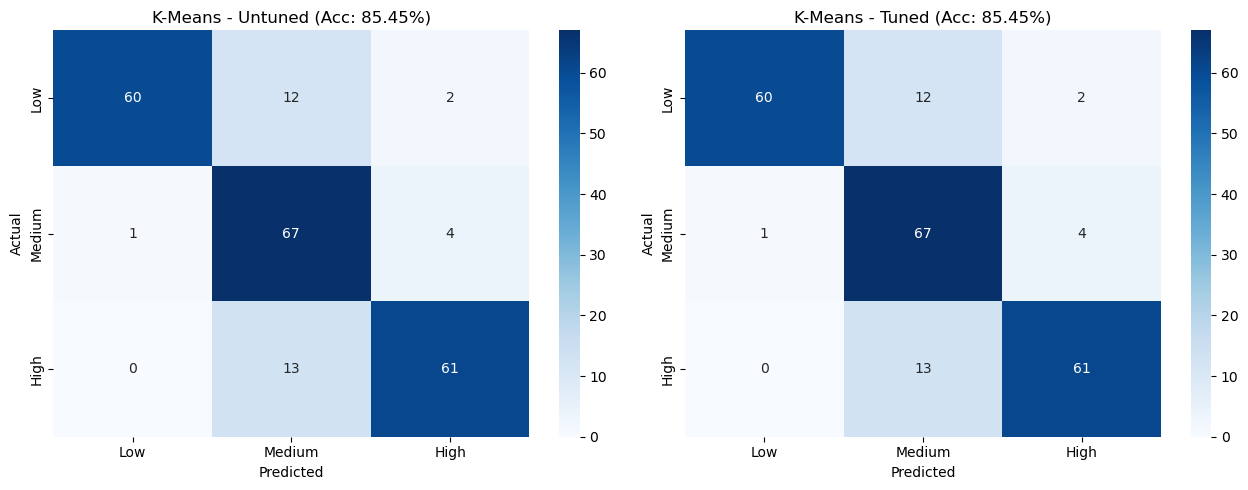

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm_tn = confusion_matrix(y_test, tuned_km_preds)

cm_unt = confusion_matrix(y_test, km_preds)
sns.heatmap(cm_unt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[0].set_title(f"K-Means - Untuned (Acc: {km_accuracy:.2%})")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_tn, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
axes[1].set_title(f"K-Means - Tuned (Acc: {tuned_km_accuracy:.2%})")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.savefig("../results/eda_visualizations/km_confusion_comparison_tuned_vs_untuned.png", dpi=150, bbox_inches='tight')
plt.show()